In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
df =pd.read_csv("Credit Card Customer Data.csv")

In [91]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [93]:
df.drop(["Sl_No","Customer Key"],axis=1,inplace=True)

In [95]:
df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Avg_Credit_Limit     660 non-null    int64
 1   Total_Credit_Cards   660 non-null    int64
 2   Total_visits_bank    660 non-null    int64
 3   Total_visits_online  660 non-null    int64
 4   Total_calls_made     660 non-null    int64
dtypes: int64(5)
memory usage: 25.9 KB


In [99]:
df.isnull().sum()

Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

In [101]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.0,18000.0,48000.0,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.0,5.0,6.0,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.0,2.0,4.0,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.0,2.0,4.0,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.0,3.0,5.0,10.0


In [103]:
import math
def plot_all_histograms(df,title_prefix = ""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols=3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5*n_cols,4*n_rows))

    for i, col in enumerate(num_cols,1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col],kde=True,bins = 30)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()
    

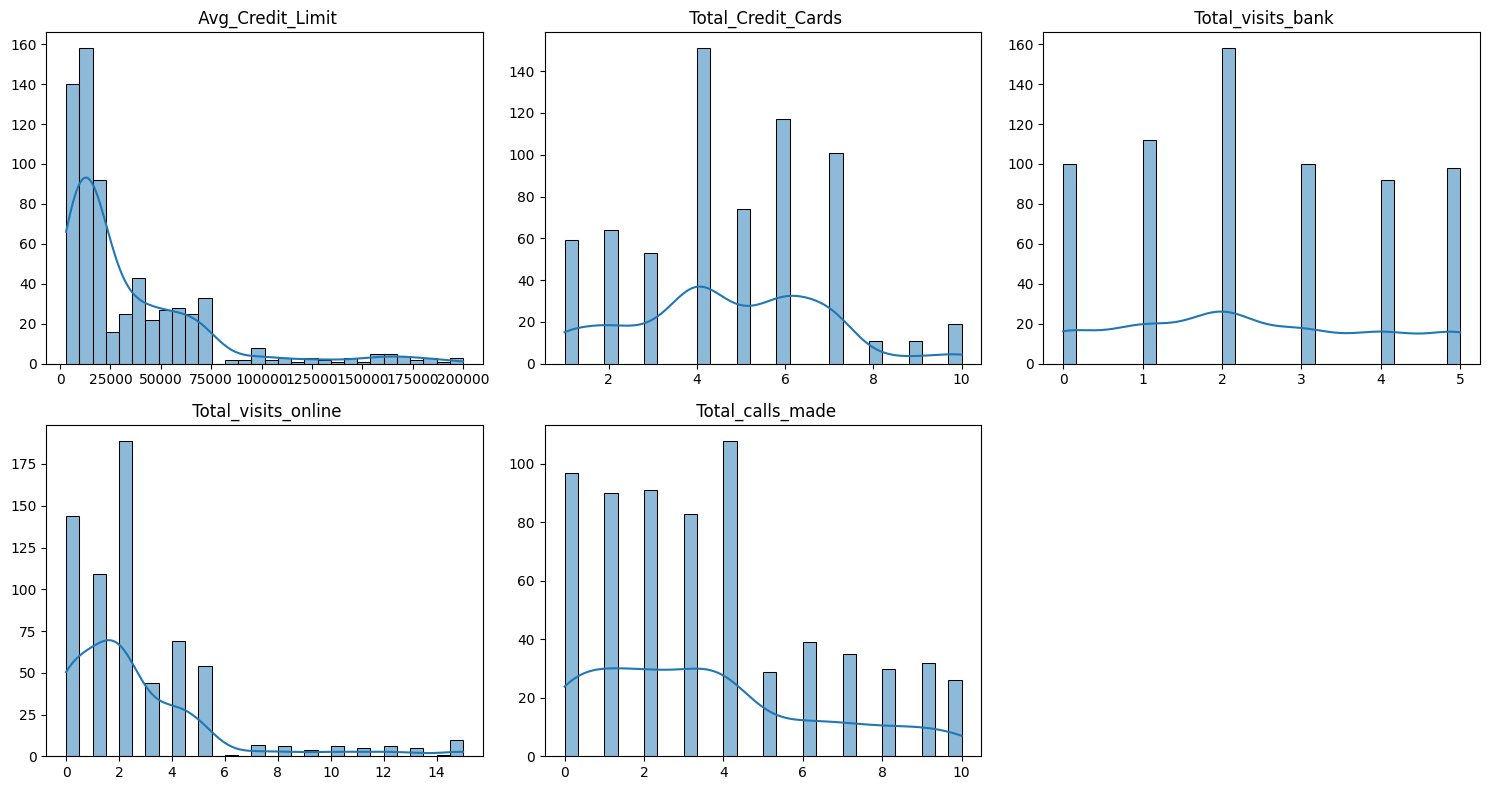

In [105]:
plot_all_histograms(df)

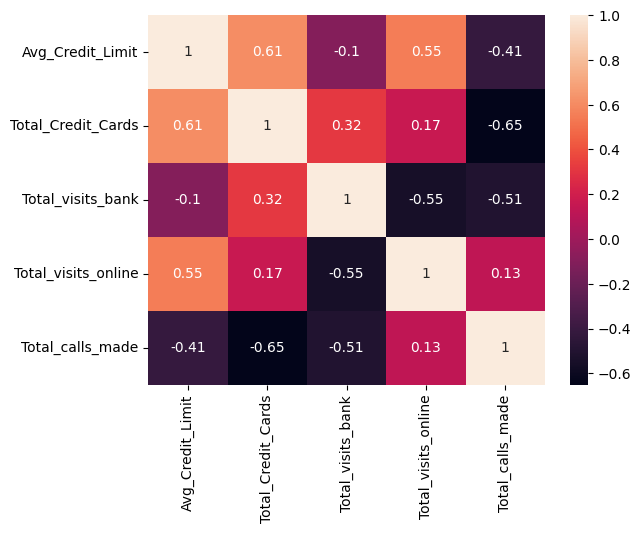

In [106]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [107]:
from sklearn.preprocessing import MinMaxScaler

In [108]:
scaler = MinMaxScaler()

In [109]:
df_scaled = scaler.fit_transform(df)

In [115]:
df.columns

Index(['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank',
       'Total_visits_online', 'Total_calls_made'],
      dtype='object')

In [119]:
df_scaled = pd.DataFrame(df_scaled,columns=[ 'Avg_Credit_Limit', 'Total_Credit_Cards',
       'Total_visits_bank', 'Total_visits_online', 'Total_calls_made'])
      

In [121]:
df_scaled.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,0.492386,0.111111,0.2,0.066667,0.0
1,0.238579,0.222222,0.0,0.666667,0.9
2,0.238579,0.666667,0.2,0.200000,0.4
3,0.137056,0.444444,0.2,0.066667,0.4
4,0.492386,0.555556,0.0,0.800000,0.3


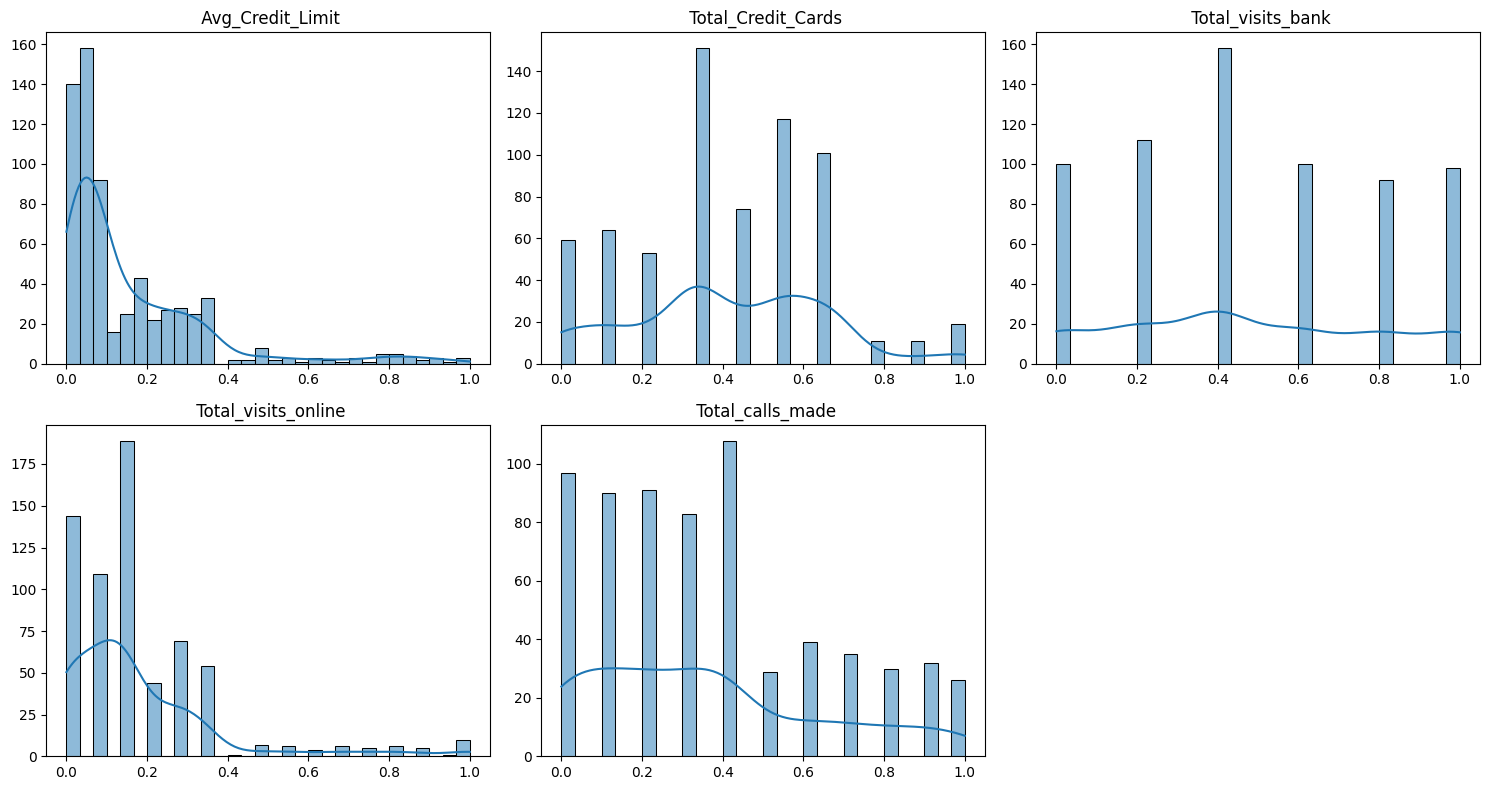

In [123]:
plot_all_histograms(df_scaled)

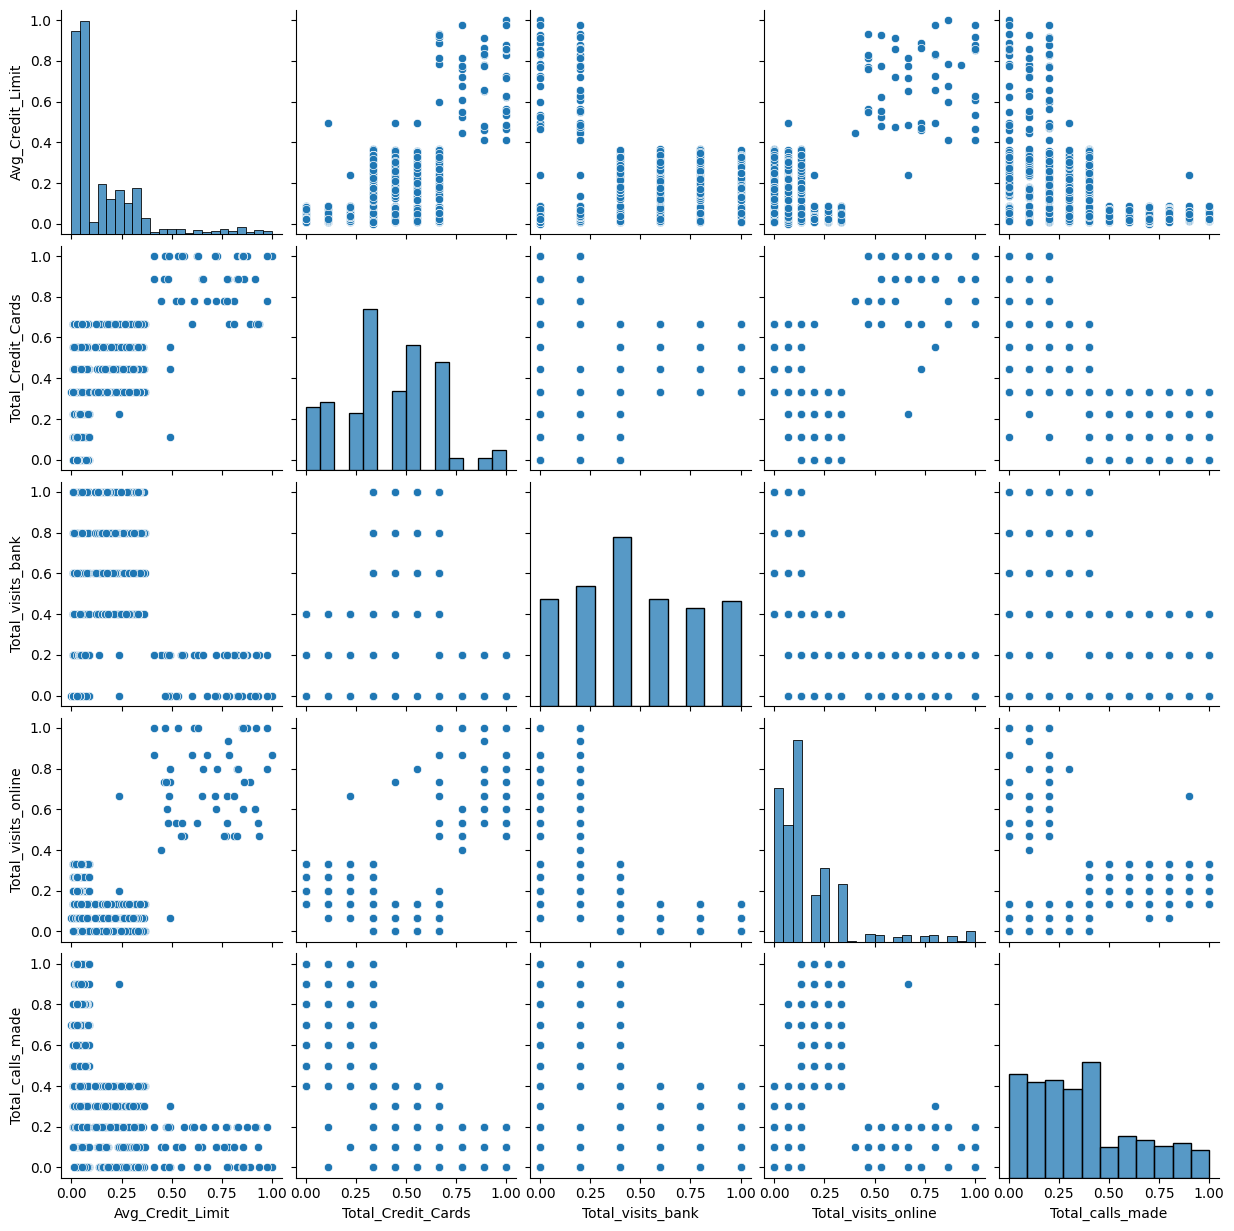

In [125]:
sns.pairplot(df_scaled)
plt.show()

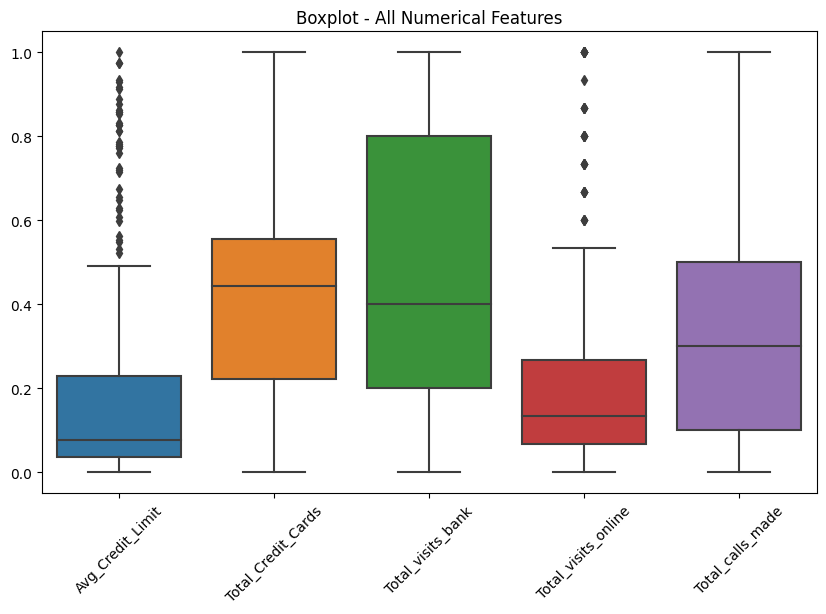

In [147]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_scaled)
plt.xticks(rotation=45)
plt.title("Boxplot - All Numerical Features")
plt.show()

In [149]:
df_scaled.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,0.492386,0.111111,0.2,0.066667,0.0
1,0.238579,0.222222,0.0,0.666667,0.9
2,0.238579,0.666667,0.2,0.200000,0.4
3,0.137056,0.444444,0.2,0.066667,0.4
4,0.492386,0.555556,0.0,0.800000,0.3


In [159]:
cols = ["Avg_Credit_Limit", "Total_visits_online"]   # outlier olan kolonlar

for col in cols:
    Q1 = df_scaled[col].quantile(0.25)
    Q3 = df_scaled[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_scaled[col] = df_scaled[col].clip(lower, upper)

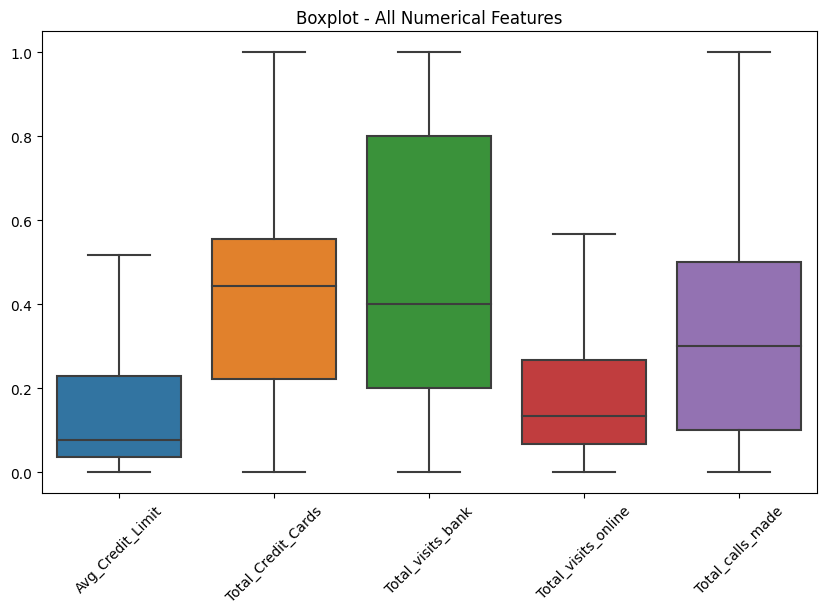

In [161]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_scaled)
plt.xticks(rotation=45)
plt.title("Boxplot - All Numerical Features")
plt.show()

In [163]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [165]:
wcss =[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

In [166]:
wcss

[191.24818316560592,
 97.78471738384982,
 61.367756284554815,
 45.40302008395956,
 39.196360336455506,
 36.01548867959074,
 33.07532487214602,
 30.26990554213998,
 28.774355002173444,
 27.476623741786145]

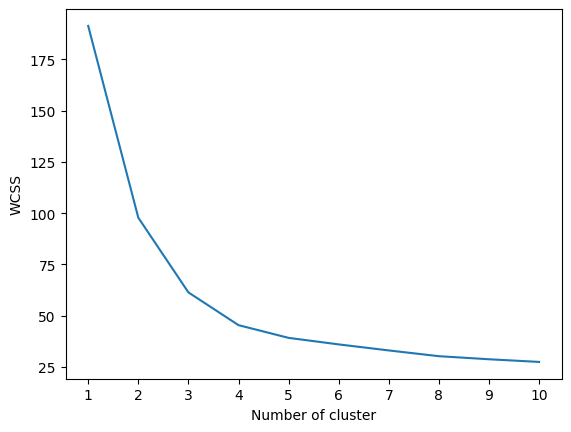

In [169]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of cluster")
plt.ylabel("WCSS")
plt.show()

In [171]:
model = KMeans(n_clusters=3)
model.fit(df_scaled)

KMeans(n_clusters=3)

In [173]:
labels =model.labels_

In [175]:
silhouette_score(df_scaled,labels)

0.5243224097959858

In [177]:
df["Class"] = labels

In [179]:
df

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Class
0,100000.0,2,1,1.0,0,1
1,50000.0,3,0,8.5,9,0
2,50000.0,7,1,3.0,4,2
3,30000.0,5,1,1.0,4,0
4,100000.0,6,0,8.5,3,2
...,...,...,...,...,...,...
655,99000.0,10,1,8.5,0,2
656,84000.0,10,1,8.5,2,2
657,105000.0,8,1,8.5,1,2
658,105000.0,10,1,8.5,0,2


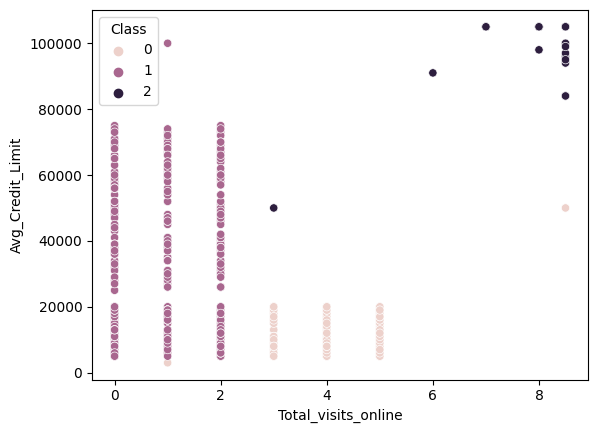

In [181]:
sns.scatterplot(data=df,x='Total_visits_online',y='Avg_Credit_Limit',hue=df['Class'])
plt.show()

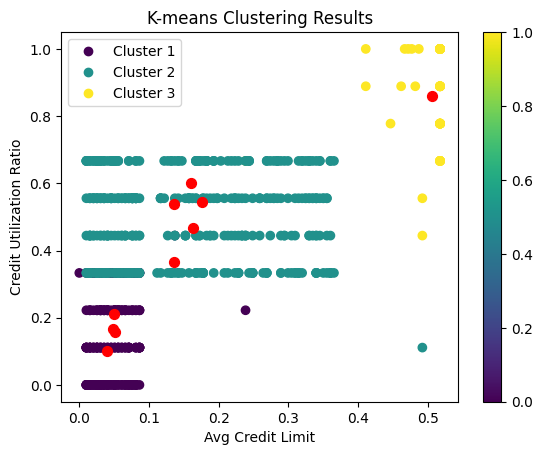

In [191]:
centroids = kmeans.cluster_centers_
scatter = plt.scatter(df_scaled.iloc[:, 0], df_scaled.iloc[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', s=50, label='Centroids')

legend_labels = [f'Cluster {i+1}' for i in range(3)]
plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels)

plt.xlabel('Avg Credit Limit')
plt.ylabel('Credit Utilization Ratio')
plt.title('K-means Clustering Results')
plt.colorbar()

## hierarchy cluster

In [193]:
import scipy.cluster.hierarchy as sch

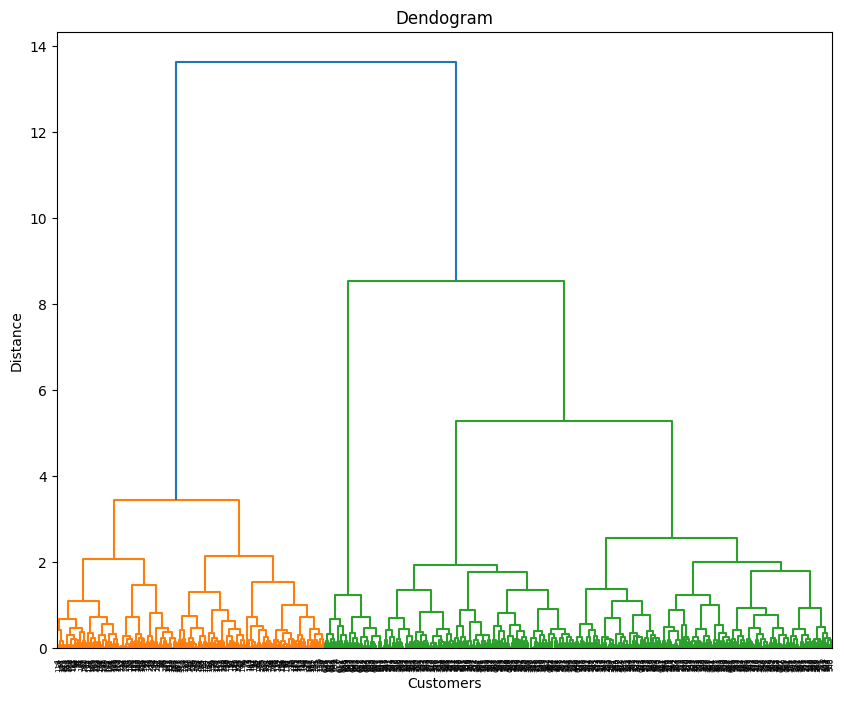

In [195]:
plt.figure(1,figsize=(10,8))
dendogram = sch.dendrogram(sch.linkage(df_scaled, method="ward"))
plt.title("Dendogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [197]:
from sklearn.cluster import AgglomerativeClustering

In [199]:
hc = AgglomerativeClustering(n_clusters=3)

In [201]:
y_hc= hc.fit_predict(df_scaled)

In [203]:
df_scaled["cluster"] = pd.DataFrame(y_hc)

In [205]:
df_scaled.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,cluster
0,0.492386,0.111111,0.2,0.066667,0.0,0
1,0.238579,0.222222,0.0,0.566667,0.9,1
2,0.238579,0.666667,0.2,0.200000,0.4,0
3,0.137056,0.444444,0.2,0.066667,0.4,1
4,0.492386,0.555556,0.0,0.566667,0.3,2


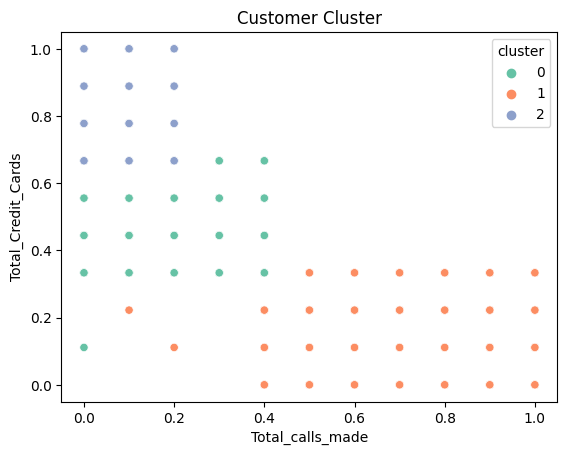

In [215]:
sns.scatterplot(data = df_scaled ,x = "Total_calls_made", y = "Total_Credit_Cards", hue = "cluster",palette="Set2")
plt.title("Customer Cluster")
plt.show()

In [211]:
from sklearn.metrics import silhouette_score
print(silhouette_score(df_scaled,y_hc))

0.6997180158745029


In [217]:
df_scaled.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,cluster
0,0.492386,0.111111,0.2,0.066667,0.0,0
1,0.238579,0.222222,0.0,0.566667,0.9,1
2,0.238579,0.666667,0.2,0.200000,0.4,0
3,0.137056,0.444444,0.2,0.066667,0.4,1
4,0.492386,0.555556,0.0,0.566667,0.3,2


In [221]:
from sklearn.metrics import calinski_harabasz_score,davies_bouldin_score

In [223]:
df =pd.read_csv("Credit Card Customer Data.csv")
df.drop(["Sl_No","Customer Key"],axis=1,inplace=True)

feature_2D = ["Avg_Credit_Limit","Total_Credit_Cards"]
feature_3D = ["Avg_Credit_Limit","Total_Credit_Cards","Total_visits_bank"]
feature_4D = ["Avg_Credit_Limit","Total_Credit_Cards","Total_visits_bank","Total_visits_online","Total_calls_made"]


for feats in [feature_2D,feature_3D,feature_4D]:
    X = df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    hc = AgglomerativeClustering(n_clusters=3)
    y_hc= hc.fit_predict(X_scaled)

    sil= silhouette_score(X_scaled,y_hc)
    db= davies_bouldin_score(X_scaled,y_hc)
    ch= calinski_harabasz_score(X_scaled,y_hc)

    print(f"\nfeatures{feats}")
    print("Silhouette Score :",sil)
    print("Davies Bouldin Score :",db)
    print("Calinski Harabasz Score :",ch)
    print("-------------------------------------")


features['Avg_Credit_Limit', 'Total_Credit_Cards']
Silhouette Score : 0.4946273929553749
Davies Bouldin Score : 0.5924963822843704
Calinski Harabasz Score : 894.0654266700408
-------------------------------------

features['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank']
Silhouette Score : 0.45736530405251924
Davies Bouldin Score : 0.7002002056582718
Calinski Harabasz Score : 567.7420167444166
-------------------------------------

features['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']
Silhouette Score : 0.5227539515660415
Davies Bouldin Score : 0.6803148676325277
Calinski Harabasz Score : 744.0066812920549
-------------------------------------
